<div style="background-color:#ED1C24; color:white; padding:20px 30px; border-radius:10px;">
<h1 style="color:white; margin:0;">Session 6.2: Probability Fundamentals</h1>
<p style="color:white; margin:5px 0 0 0;">Practical Lab — From Descriptive Stats to Bayes' Theorem</p>
</div>

## Learning Objectives

1. Compute descriptive statistics (mean, median, mode, variance, std, skewness, kurtosis)
2. Define sample space, events, and compute probabilities from data
3. Distinguish **mutually exclusive** from **independent** events
4. Compute **conditional probability** P(A|B) and understand P(A|B) ≠ P(B|A)
5. Apply the complement, addition, and multiplication rules
6. Use **Bayes' theorem** to solve real-world problems (spam filtering, factory QC)
7. Test for independence between events using data

## Business Context: Gmail's Spam Filter

In 2004, Gmail launched with a spam filter powered by **Bayes' theorem**. The filter asks:
"Given that this email contains the word 'free', what is the probability it is spam?"

Today, Gmail blocks **10 million spam emails per minute** using exactly the P(A|B) formula
you will learn in this notebook. By the end, you will be able to build your own spam classifier.

## Setup

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)
print("Setup complete!")

Setup complete!


<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 1: Descriptive Statistics</h2>
</div>

Before building any ML model, a data scientist **always** starts by summarizing the data.
We need to answer three questions:
- **Central tendency:** What is the typical value? (mean, median, mode)
- **Spread:** How spread out are the values? (variance, standard deviation)
- **Shape:** Is the distribution symmetric or lopsided? (skewness, kurtosis)

We'll use a realistic salary dataset to explore all three.

In [2]:
# Created a realistic salary dataset: most employees earn moderate salaries,
# a few senior roles earn more, and a handful of executives earn much more.
# This creates a right-skewed distribution — very common in real salary data.

salaries = np.concatenate([
    np.random.normal(35000, 8000, 160),   # Most employees: ~35K
    np.random.normal(80000, 15000, 30),    # Senior roles: ~80K
    np.random.normal(200000, 30000, 10)    # Executives: ~200K
])
salaries = np.clip(salaries, 15000, None)  # Minimum wage floor

# --- CENTRAL TENDENCY ---
mean_sal = np.mean(salaries)
median_sal = np.median(salaries)

print("=" * 60)
print("DESCRIPTIVE STATISTICS: Employee Salaries (₹)")
print("=" * 60)
print(f"\nDataset: {len(salaries)} employees\n")

print("--- CENTRAL TENDENCY ---")
print(f"  Mean (average):    ₹{mean_sal:>10,.0f}")
print(f"  Median (middle):   ₹{median_sal:>10,.0f}")
print(f"  Difference:        ₹{mean_sal - median_sal:>10,.0f}")
print(f"\n  → Mean > Median by ₹{mean_sal - median_sal:,.0f}")
print(f"    This tells us: data is RIGHT-SKEWED")
print(f"    (high-earning executives pull the mean UP,")
print(f"     but the median stays near the typical employee)")

# --- SPREAD ---
var_pop = np.var(salaries)             # Population variance (ddof=0)
var_sample = np.var(salaries, ddof=1)  # Sample variance (ddof=1)
std_sample = np.std(salaries, ddof=1)

print(f"\n--- SPREAD (DISPERSION) ---")
print(f"  Population variance (N):   {var_pop:>15,.0f}")
print(f"  Sample variance (N-1):     {var_sample:>15,.0f}")
print(f"  Sample std deviation:      ₹{std_sample:>10,.0f}")
print(f"\n  → The 'typical' salary deviates ₹{std_sample:,.0f} from the mean")
print(f"  → Why N-1 (Bessel's correction)?")
print(f"    When computing from a SAMPLE (not entire population),")
print(f"    dividing by N underestimates true variance.")
print(f"    N-1 corrects this bias.")
print(f"    In pandas: df.std() uses N-1 by default.")

DESCRIPTIVE STATISTICS: Employee Salaries (₹)

Dataset: 200 employees

--- CENTRAL TENDENCY ---
  Mean (average):    ₹    49,631
  Median (middle):   ₹    37,032
  Difference:        ₹    12,599

  → Mean > Median by ₹12,599
    This tells us: data is RIGHT-SKEWED
    (high-earning executives pull the mean UP,
     but the median stays near the typical employee)

--- SPREAD (DISPERSION) ---
  Population variance (N):     1,486,272,905
  Sample variance (N-1):       1,493,741,613
  Sample std deviation:      ₹    38,649

  → The 'typical' salary deviates ₹38,649 from the mean
  → Why N-1 (Bessel's correction)?
    When computing from a SAMPLE (not entire population),
    dividing by N underestimates true variance.
    N-1 corrects this bias.
    In pandas: df.std() uses N-1 by default.


### Skewness: Is Your Data Lopsided?

**Skewness** measures how asymmetric a distribution is:
- **Skewness ≈ 0:** Symmetric (bell curve). Mean ≈ Median. Example: adult heights.
- **Skewness > 0 (positive/right):** Long tail on the RIGHT. Mean > Median. Example: salaries, house prices.
- **Skewness < 0 (negative/left):** Long tail on the LEFT. Mean < Median. Example: easy exam scores.

**Rule of thumb:** |skewness| < 0.5 = approximately symmetric. 0.5-1.0 = moderate. >1.0 = high skew.

**Why it matters for ML:** Many algorithms work best with roughly symmetric features. Highly skewed features may need a log transform.

--- SHAPE: SKEWNESS ---
  Skewness value: 2.8595
  Direction: RIGHT (positive)
  Interpretation: Highly skewed

  → Positive skew means: long tail on the RIGHT side.
    Most employees earn around ₹37,032 (the median),
    but a few high earners (₹2L+) stretch the distribution right.


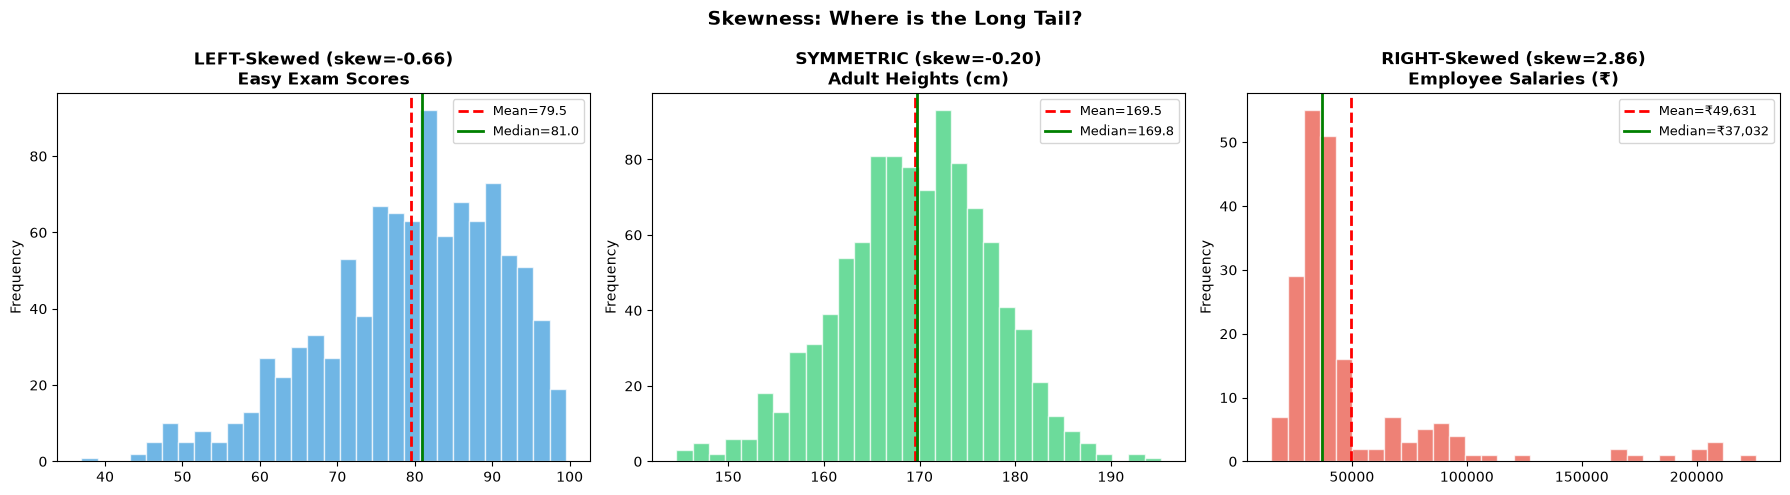


--- SKEWNESS VISUAL SUMMARY ---
  Left-skewed:  Mean < Median   (tail stretches LEFT)
  Symmetric:    Mean ≈ Median   (balanced)
  Right-skewed: Mean > Median   (tail stretches RIGHT)


In [3]:
# Let's compute skewness for our salary data, then visualize
# three types of skewness side by side.

skew_val = stats.skew(salaries)
print("--- SHAPE: SKEWNESS ---")
print(f"  Skewness value: {skew_val:.4f}")

if abs(skew_val) < 0.5:
    skew_label = "Approximately symmetric"
elif abs(skew_val) < 1.0:
    skew_label = "Moderately skewed"
else:
    skew_label = "Highly skewed"
direction = "RIGHT (positive)" if skew_val > 0 else "LEFT (negative)"
print(f"  Direction: {direction}")
print(f"  Interpretation: {skew_label}")
print(f"\n  → Positive skew means: long tail on the RIGHT side.")
print(f"    Most employees earn around ₹{median_sal:,.0f} (the median),")
print(f"    but a few high earners (₹2L+) stretch the distribution right.")

# Visualization: three types of skewness
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left-skewed (easy exam scores — most score high)
easy_exam = np.clip(np.random.beta(8, 2, 1000) * 100, 0, 100)
axes[0].hist(easy_exam, bins=30, color='#3498DB', alpha=0.7, edgecolor='white')
axes[0].axvline(np.mean(easy_exam), color='red', lw=2, ls='--', label=f'Mean={np.mean(easy_exam):.1f}')
axes[0].axvline(np.median(easy_exam), color='green', lw=2, ls='-', label=f'Median={np.median(easy_exam):.1f}')
axes[0].set_title(f'LEFT-Skewed (skew={stats.skew(easy_exam):.2f})\nEasy Exam Scores', fontweight='bold')
axes[0].legend(fontsize=9)

# Symmetric (adult heights)
heights = np.random.normal(170, 8, 1000)
axes[1].hist(heights, bins=30, color='#2ECC71', alpha=0.7, edgecolor='white')
axes[1].axvline(np.mean(heights), color='red', lw=2, ls='--', label=f'Mean={np.mean(heights):.1f}')
axes[1].axvline(np.median(heights), color='green', lw=2, ls='-', label=f'Median={np.median(heights):.1f}')
axes[1].set_title(f'SYMMETRIC (skew={stats.skew(heights):.2f})\nAdult Heights (cm)', fontweight='bold')
axes[1].legend(fontsize=9)

# Right-skewed (salaries)
axes[2].hist(salaries, bins=30, color='#E74C3C', alpha=0.7, edgecolor='white')
axes[2].axvline(mean_sal, color='red', lw=2, ls='--', label=f'Mean=₹{mean_sal:,.0f}')
axes[2].axvline(median_sal, color='green', lw=2, ls='-', label=f'Median=₹{median_sal:,.0f}')
axes[2].set_title(f'RIGHT-Skewed (skew={skew_val:.2f})\nEmployee Salaries (₹)', fontweight='bold')
axes[2].legend(fontsize=9)

for ax in axes:
    ax.set_ylabel('Frequency')
plt.suptitle('Skewness: Where is the Long Tail?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n--- SKEWNESS VISUAL SUMMARY ---")
print("  Left-skewed:  Mean < Median   (tail stretches LEFT)")
print("  Symmetric:    Mean ≈ Median   (balanced)")
print("  Right-skewed: Mean > Median   (tail stretches RIGHT)")

### Kurtosis: How Extreme Are Your Outliers?

**Kurtosis** measures how heavy the **tails** of a distribution are — how likely are EXTREME values?

Three types (using **excess kurtosis** where normal distribution = 0):
- **Mesokurtic (kurtosis ≈ 0):** Normal-like tails. Example: heights, IQ scores.
- **Leptokurtic (kurtosis > 0):** HEAVY tails, sharp peak. More extreme outliers than expected. Example: stock returns — most days are calm, but crashes happen more than a bell curve predicts.
- **Platykurtic (kurtosis < 0):** LIGHT tails, flat peak. Fewer extremes. Example: rolling a fair die (uniform).

Python's `scipy.stats.kurtosis()` uses the **Fisher definition** (excess kurtosis, normal = 0).

In [4]:
# Compute kurtosis for our salary data
kurt_val = stats.kurtosis(salaries)  # Fisher definition: normal = 0

print("--- SHAPE: KURTOSIS ---")
print(f"  Excess kurtosis: {kurt_val:.4f}")

if kurt_val > 0:
    kurt_type = "Leptokurtic (HEAVY tails — more extreme outliers than normal)"
elif kurt_val < 0:
    kurt_type = "Platykurtic (LIGHT tails — fewer extreme values than normal)"
else:
    kurt_type = "Mesokurtic (normal-like tails)"

print(f"  Type: {kurt_type}")
print(f"\n  What this means for our salary data:")
print(f"  → Kurtosis > 0 tells us extreme values (very high salaries)")
print(f"    occur MORE OFTEN than a normal distribution would predict.")
print(f"  → Practical impact: outlier-sensitive algorithms (like linear")
print(f"    regression) may be pulled by these extremes.")
print(f"  → Solutions: log transform, outlier capping, or robust algorithms.")

# Quick summary table
print(f"\n{'='*50}")
print(f"  COMPLETE DESCRIPTIVE PROFILE")
print(f"{'='*50}")
print(f"  Mean:       ₹{mean_sal:>10,.0f}")
print(f"  Median:     ₹{median_sal:>10,.0f}")
print(f"  Std Dev:    ₹{std_sample:>10,.0f}")
print(f"  Skewness:   {skew_val:>10.4f}  ({direction})")
print(f"  Kurtosis:   {kurt_val:>10.4f}  ({kurt_type.split('(')[0].strip()})")

--- SHAPE: KURTOSIS ---
  Excess kurtosis: 8.2886
  Type: Leptokurtic (HEAVY tails — more extreme outliers than normal)

  What this means for our salary data:
  → Kurtosis > 0 tells us extreme values (very high salaries)
    occur MORE OFTEN than a normal distribution would predict.
  → Practical impact: outlier-sensitive algorithms (like linear
    regression) may be pulled by these extremes.
  → Solutions: log transform, outlier capping, or robust algorithms.

  COMPLETE DESCRIPTIVE PROFILE
  Mean:       ₹    49,631
  Median:     ₹    37,032
  Std Dev:    ₹    38,649
  Skewness:       2.8595  (RIGHT (positive))
  Kurtosis:       8.2886  (Leptokurtic)


<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 2: Probability Basics</h2>
</div>

**Probability** measures how likely an event is to occur, as a number between 0 (impossible) and 1 (certain).

$$P(A) = \frac{\text{Number of outcomes where A happens}}{\text{Total number of possible outcomes}}$$

We'll use a **student survey dataset** to make probability concrete and hands-on.
We'll also define two critical types of events that beginners often confuse:
- **Mutually exclusive:** Cannot happen at the same time (they BLOCK each other)
- **Independent:** One doesn't affect the other (they IGNORE each other)

In [5]:
# Create a student survey dataset with 200 students.
# We'll use this dataset throughout the rest of the notebook
# to compute all types of probability.

np.random.seed(42)
n_students = 200

students = pd.DataFrame({
    'student_id': range(1, n_students + 1),
    'gender': np.random.choice(['Male', 'Female'], n_students, p=[0.55, 0.45]),
    'year': np.random.choice(['1st', '2nd', '3rd', '4th'], n_students, p=[0.30, 0.28, 0.22, 0.20]),
    'likes_python': np.random.choice(['Yes', 'No'], n_students, p=[0.65, 0.35]),
    'plays_sports': np.random.choice(['Yes', 'No'], n_students, p=[0.40, 0.60]),
    'gpa': np.round(np.clip(np.random.normal(7.5, 1.2, n_students), 4.0, 10.0), 1)
})

total = len(students)
print("=" * 60)
print("PROBABILITY BASICS: Student Survey (200 students)")
print("=" * 60)
print(f"\nFirst 5 rows of our dataset:")
print(students.head().to_string(index=False))

# --- SIMPLE PROBABILITY ---
n_python = (students['likes_python'] == 'Yes').sum()
p_python = n_python / total

print(f"\n--- EVENT: 'Student likes Python' ---")
print(f"  Students who like Python: {n_python} out of {total}")
print(f"  P(likes Python) = {n_python}/{total} = {p_python:.4f} = {p_python*100:.1f}%")
print(f"\n  This means: if you randomly pick a student from this class,")
print(f"  there is a {p_python*100:.1f}% chance they like Python.")

n_sports = (students['plays_sports'] == 'Yes').sum()
p_sports = n_sports / total
print(f"\n--- EVENT: 'Student plays sports' ---")
print(f"  Students who play sports: {n_sports} out of {total}")
print(f"  P(plays sports) = {n_sports}/{total} = {p_sports:.4f} = {p_sports*100:.1f}%")

# --- MUTUALLY EXCLUSIVE ---
n_1st = (students['year'] == '1st').sum()
n_4th = (students['year'] == '4th').sum()
n_1st_and_4th = ((students['year'] == '1st') & (students['year'] == '4th')).sum()

print(f"\n--- MUTUALLY EXCLUSIVE EVENTS ---")
print(f"  Event A: 'Student is 1st year'  → {n_1st} students")
print(f"  Event B: 'Student is 4th year'  → {n_4th} students")
print(f"  Event (A AND B): Both 1st AND 4th → {n_1st_and_4th} students")
print(f"\n  P(A AND B) = {n_1st_and_4th}/{total} = {n_1st_and_4th/total}")
print(f"  → IMPOSSIBLE! A student cannot be in two years at once.")
print(f"  → These events are MUTUALLY EXCLUSIVE: P(A AND B) = 0")
print(f"\n  Therefore: P(1st OR 4th) = P(1st) + P(4th)  [no overlap!]")
print(f"           = {n_1st}/{total} + {n_4th}/{total}")
print(f"           = {(n_1st + n_4th)/total:.4f} = {(n_1st + n_4th)/total*100:.1f}%")

PROBABILITY BASICS: Student Survey (200 students)

First 5 rows of our dataset:
 student_id gender year likes_python plays_sports  gpa
          1   Male  3rd          Yes          Yes  6.6
          2 Female  1st           No          Yes  8.1
          3 Female  1st          Yes          Yes  9.8
          4 Female  4th           No          Yes  9.1
          5   Male  3rd          Yes          Yes  9.4

--- EVENT: 'Student likes Python' ---
  Students who like Python: 127 out of 200
  P(likes Python) = 127/200 = 0.6350 = 63.5%

  This means: if you randomly pick a student from this class,
  there is a 63.5% chance they like Python.

--- EVENT: 'Student plays sports' ---
  Students who play sports: 89 out of 200
  P(plays sports) = 89/200 = 0.4450 = 44.5%

--- MUTUALLY EXCLUSIVE EVENTS ---
  Event A: 'Student is 1st year'  → 59 students
  Event B: 'Student is 4th year'  → 39 students
  Event (A AND B): Both 1st AND 4th → 0 students

  P(A AND B) = 0/200 = 0.0
  → IMPOSSIBLE! A stude

In [6]:
students

,student_id,gender,year,likes_python,plays_sports,gpa
0,1,Male,3rd,Yes,Yes,6.6
1,2,Female,1st,No,Yes,8.1
2,3,Female,1st,Yes,Yes,9.8
3,4,Female,4th,No,Yes,9.1
4,5,Male,3rd,Yes,Yes,9.4
...,...,...,...,...,...,...
195,196,Male,4th,Yes,No,5.7
196,197,Female,4th,No,No,7.8
197,198,Female,2nd,Yes,No,8.6
198,199,Female,3rd,Yes,No,7.6


<div style="background-color:#ED1C24; color:gray; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 3: Conditional Probability</h2>
</div>

**Conditional probability** P(A|B) answers: "What is the probability of **A, given that B has happened**?"

$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

**Think of it as ZOOMING IN.** Instead of looking at all 200 students, you zoom into ONLY the students where B is true, and ask: among those, how many also have A?

<div style="background: #FEF9E7; color: gray; border-left: 5px solid #F39C12; padding: 15px; margin: 15px 0;">
<strong>Critical:</strong> P(A|B) ≠ P(B|A). The ORDER of the condition matters enormously!
</div>

In [8]:
# Conditional probability using a frequency table (cross-tabulation).
# A frequency table shows how many students fall into each combination
# of two categories — it's the perfect tool for computing P(A|B).

print("=" * 60)
print("CONDITIONAL PROBABILITY: P(A|B)")
print("=" * 60)

# Cross-tabulation: likes_python vs plays_sports
freq_table = pd.crosstab(students['likes_python'], students['plays_sports'],
                          margins=True, margins_name='Total')
print(f"\n--- FREQUENCY TABLE ---")
print(f"  (Rows: Likes Python, Columns: Plays Sports)\n")
print(freq_table.to_string())

# Extract the counts we need
n_python_yes = (students['likes_python'] == 'Yes').sum()
n_sports_yes = (students['plays_sports'] == 'Yes').sum()
n_both = ((students['likes_python'] == 'Yes') & (students['plays_sports'] == 'Yes')).sum()

# Step-by-step conditional probability
print(f"\n--- COMPUTING P(likes Python | plays sports) ---")
print(f"  Question: 'Among students who play sports, what fraction likes Python?'")
print(f"\n  Step 1: ZOOM INTO 'plays sports = Yes'")
print(f"          → {n_sports_yes} students play sports")
print(f"\n  Step 2: Among those {n_sports_yes}, how many ALSO like Python?")
print(f"          → {n_both} students both play sports AND like Python")
print(f"\n  Step 3: Divide!")
print(f"          P(Python | Sports) = {n_both} / {n_sports_yes} = {n_both/n_sports_yes:.4f}")
print(f"          = {n_both/n_sports_yes*100:.1f}%")

# P(A|B) ≠ P(B|A)
p_python_given_sports = n_both / n_sports_yes
p_sports_given_python = n_both / n_python_yes

print(f"\n--- P(A|B) ≠ P(B|A) — THE ORDER MATTERS! ---")
print(f"  P(likes Python | plays sports) = {p_python_given_sports:.4f}")
print(f"  P(plays sports | likes Python) = {p_sports_given_python:.4f}")
print(f"\n  These are DIFFERENT questions:")
print(f"  First:  'Among athletes, what % like Python?'")
print(f"  Second: 'Among Python fans, what % play sports?'")
print(f"\n  The '|' tells you which GROUP to zoom into.")
print(f"  P(A|B): zoom into B, then check for A")
print(f"  P(B|A): zoom into A, then check for B")

CONDITIONAL PROBABILITY: P(A|B)

--- FREQUENCY TABLE ---
  (Rows: Likes Python, Columns: Plays Sports)

plays_sports   No  Yes  Total
likes_python                 
No             43   30     73
Yes            68   59    127
Total         111   89    200

--- COMPUTING P(likes Python | plays sports) ---
  Question: 'Among students who play sports, what fraction likes Python?'

  Step 1: ZOOM INTO 'plays sports = Yes'
          → 89 students play sports

  Step 2: Among those 89, how many ALSO like Python?
          → 59 students both play sports AND like Python

  Step 3: Divide!
          P(Python | Sports) = 59 / 89 = 0.6629
          = 66.3%

--- P(A|B) ≠ P(B|A) — THE ORDER MATTERS! ---
  P(likes Python | plays sports) = 0.6629
  P(plays sports | likes Python) = 0.4646

  These are DIFFERENT questions:
  First:  'Among athletes, what % like Python?'
  Second: 'Among Python fans, what % play sports?'

  The '|' tells you which GROUP to zoom into.
  P(A|B): zoom into B, then check for 

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 4: Probability Rules</h2>
</div>

Now that we understand conditional probability, we can use the **three probability rules**.
The key insight: the **multiplication rule** uses P(B|A) — which we already understand!

1. **Complement:** P(NOT A) = 1 - P(A)
2. **Addition (OR):** P(A ∪ B) = P(A) + P(B) - P(A ∩ B)
   - Special case (mutually exclusive): P(A ∪ B) = P(A) + P(B)
3. **Multiplication (AND):** P(A ∩ B) = P(A) × P(B|A)
   - Special case (independent): P(A ∩ B) = P(A) × P(B)

In [9]:
# Apply all three probability rules to our student dataset.

print("=" * 60)
print("PROBABILITY RULES IN ACTION")
print("=" * 60)

# --- RULE 1: COMPLEMENT ---
p_python_val = n_python_yes / total
p_not_python = 1 - p_python_val

print(f"\n--- RULE 1: COMPLEMENT ---")
print(f"  P(likes Python)         = {p_python_val:.4f}")
print(f"  P(does NOT like Python)  = 1 - {p_python_val:.4f} = {p_not_python:.4f}")
print(f"  Check: {p_python_val:.4f} + {p_not_python:.4f} = {p_python_val + p_not_python:.4f} ✓")

# --- RULE 2: ADDITION (UNION) ---
n_python_or_sports = ((students['likes_python'] == 'Yes') | (students['plays_sports'] == 'Yes')).sum()
p_union = n_python_or_sports / total
p_sports_val = n_sports_yes / total
p_intersection = n_both / total

print(f"\n--- RULE 2: ADDITION (OR) ---")
print(f"  P(Python OR Sports) = P(Python) + P(Sports) - P(Python AND Sports)")
print(f"                      = {p_python_val:.4f} + {p_sports_val:.4f} - {p_intersection:.4f}")
print(f"                      = {p_python_val + p_sports_val - p_intersection:.4f}")
print(f"  Direct count:         {n_python_or_sports}/{total} = {p_union:.4f} ✓")
print(f"\n  Why subtract P(A ∩ B)? Because {n_both} students are in BOTH groups.")
print(f"  If we just add, we count them TWICE.")

# Mutually exclusive special case
n_1st_or_4th = ((students['year'] == '1st') | (students['year'] == '4th')).sum()
print(f"\n  SPECIAL CASE — Mutually Exclusive:")
print(f"  P(1st year OR 4th year) = P(1st) + P(4th)  [no overlap!]")
print(f"                          = {n_1st/total:.4f} + {n_4th/total:.4f}")
print(f"                          = {(n_1st + n_4th)/total:.4f}")
print(f"  Direct count: {n_1st_or_4th}/{total} = {n_1st_or_4th/total:.4f} ✓")

# --- RULE 3: MULTIPLICATION (AND) ---
print(f"\n--- RULE 3: MULTIPLICATION (AND) ---")
print(f"  P(Python AND Sports) = P(Python) × P(Sports | Python)")
print(f"                       = {p_python_val:.4f} × {p_sports_given_python:.4f}")
print(f"                       = {p_python_val * p_sports_given_python:.4f}")
print(f"  Direct count:          {n_both}/{total} = {p_intersection:.4f} ✓")

# Card example — concrete, no prior knowledge needed
print(f"\n  --- CARD EXAMPLE (without replacement) ---")
print(f"  P(1st card Ace) = 4/52 = {4/52:.4f}")
print(f"  P(2nd card Ace | 1st was Ace) = 3/51 = {3/51:.4f}")
print(f"  P(both Aces) = (4/52) × (3/51) = {(4/52)*(3/51):.6f}")
print(f"               ≈ {(4/52)*(3/51)*100:.2f}% chance")
print(f"\n  After drawing the 1st Ace, only 3 Aces remain in 51 cards.")
print(f"  The events are DEPENDENT: the first draw changed the second.")

PROBABILITY RULES IN ACTION

--- RULE 1: COMPLEMENT ---
  P(likes Python)         = 0.6350
  P(does NOT like Python)  = 1 - 0.6350 = 0.3650
  Check: 0.6350 + 0.3650 = 1.0000 ✓

--- RULE 2: ADDITION (OR) ---
  P(Python OR Sports) = P(Python) + P(Sports) - P(Python AND Sports)
                      = 0.6350 + 0.4450 - 0.2950
                      = 0.7850
  Direct count:         157/200 = 0.7850 ✓

  Why subtract P(A ∩ B)? Because 59 students are in BOTH groups.
  If we just add, we count them TWICE.

  SPECIAL CASE — Mutually Exclusive:
  P(1st year OR 4th year) = P(1st) + P(4th)  [no overlap!]
                          = 0.2950 + 0.1950
                          = 0.4900
  Direct count: 98/200 = 0.4900 ✓

--- RULE 3: MULTIPLICATION (AND) ---
  P(Python AND Sports) = P(Python) × P(Sports | Python)
                       = 0.6350 × 0.4646
                       = 0.2950
  Direct count:          59/200 = 0.2950 ✓

  --- CARD EXAMPLE (without replacement) ---
  P(1st card Ace) = 4/52 = 0.0

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 5: Bayes' Theorem</h2>
</div>

**Bayes' theorem** answers: "We know P(B|A). How do we compute P(A|B)?" — i.e., how to **flip the conditional**.

$$P(A|B) = \frac{P(B|A) \times P(A)}{P(B)}$$

Each piece has a name:
- **P(A) = Prior** — our belief BEFORE seeing evidence
- **P(B|A) = Likelihood** — how likely is this evidence IF our hypothesis is true?
- **P(B) = Evidence** — how common is this evidence overall?
- **P(A|B) = Posterior** — our UPDATED belief AFTER seeing evidence

We'll work through two complete examples step by step.

In [10]:
# EXAMPLE 1: EMAIL SPAM FILTER
# This is exactly how Gmail's original spam filter worked.
#
# Setup:
# - You receive 1000 emails per day
# - 30% are spam, 70% are legitimate
# - 80% of spam emails contain the word "free"
# - Only 10% of legitimate emails contain "free"
#
# Question: An email contains "free". Is it spam?

print("=" * 60)
print("BAYES' THEOREM: EMAIL SPAM FILTER")
print("=" * 60)

p_spam = 0.30
p_legit = 1 - p_spam
p_free_given_spam = 0.80
p_free_given_legit = 0.10

print(f"\n--- WHAT WE KNOW ---")
print(f"  P(spam)              = {p_spam:.2f}  (30% of emails are spam)")
print(f"  P(legit)             = {p_legit:.2f}  (70% are legitimate)")
print(f"  P('free' | spam)     = {p_free_given_spam:.2f}  (80% of spam has 'free')")
print(f"  P('free' | legit)    = {p_free_given_legit:.2f}  (10% of legit has 'free')")

print(f"\n--- WHAT WE WANT ---")
print(f"  P(spam | 'free') = ?  (Is this email spam?)")

# Step 1: Law of Total Probability
p_free = p_free_given_spam * p_spam + p_free_given_legit * p_legit
print(f"\n--- STEP 1: P('free') via Law of Total Probability ---")
print(f"  P('free') = P('free'|spam) × P(spam) + P('free'|legit) × P(legit)")
print(f"            = {p_free_given_spam} × {p_spam} + {p_free_given_legit} × {p_legit}")
print(f"            = {p_free_given_spam * p_spam:.4f} + {p_free_given_legit * p_legit:.4f}")
print(f"            = {p_free:.4f}")
print(f"  → {p_free*100:.1f}% of ALL emails contain 'free'")

# Step 2: Bayes' Theorem
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print(f"\n--- STEP 2: Apply Bayes' Theorem ---")
print(f"  P(spam|'free') = P('free'|spam) × P(spam) / P('free')")
print(f"                 = {p_free_given_spam} × {p_spam} / {p_free:.4f}")
print(f"                 = {p_free_given_spam * p_spam:.4f} / {p_free:.4f}")
print(f"                 = {p_spam_given_free:.4f}")
print(f"                 = {p_spam_given_free*100:.1f}%")

print(f"\n--- INTERPRETATION ---")
print(f"  BEFORE seeing 'free': P(spam) = {p_spam*100:.0f}% (prior)")
print(f"  AFTER seeing 'free':  P(spam) = {p_spam_given_free*100:.1f}% (posterior)")
print(f"  → The word 'free' shifted our belief from {p_spam*100:.0f}% to {p_spam_given_free*100:.1f}%!")
print(f"  → 'free' is STRONG evidence for spam.")

# Verify with simulation
print(f"\n--- VERIFICATION BY SIMULATION (1,000,000 emails) ---")
n_emails = 1_000_000
np.random.seed(42)
is_spam = np.random.random(n_emails) < p_spam
has_free = np.where(is_spam,
                     np.random.random(n_emails) < p_free_given_spam,
                     np.random.random(n_emails) < p_free_given_legit)

emails_with_free = has_free.sum()
spam_with_free = (is_spam & has_free).sum()
simulated_p = spam_with_free / emails_with_free

print(f"  Emails with 'free': {emails_with_free:,}")
print(f"  Of those, spam:     {spam_with_free:,}")
print(f"  Simulated P(spam|'free') = {simulated_p:.4f}")
print(f"  Bayes formula result     = {p_spam_given_free:.4f}")
print(f"  → Match! ✓")

BAYES' THEOREM: EMAIL SPAM FILTER

--- WHAT WE KNOW ---
  P(spam)              = 0.30  (30% of emails are spam)
  P(legit)             = 0.70  (70% are legitimate)
  P('free' | spam)     = 0.80  (80% of spam has 'free')
  P('free' | legit)    = 0.10  (10% of legit has 'free')

--- WHAT WE WANT ---
  P(spam | 'free') = ?  (Is this email spam?)

--- STEP 1: P('free') via Law of Total Probability ---
  P('free') = P('free'|spam) × P(spam) + P('free'|legit) × P(legit)
            = 0.8 × 0.3 + 0.1 × 0.7
            = 0.2400 + 0.0700
            = 0.3100
  → 31.0% of ALL emails contain 'free'

--- STEP 2: Apply Bayes' Theorem ---
  P(spam|'free') = P('free'|spam) × P(spam) / P('free')
                 = 0.8 × 0.3 / 0.3100
                 = 0.2400 / 0.3100
                 = 0.7742
                 = 77.4%

--- INTERPRETATION ---
  BEFORE seeing 'free': P(spam) = 30% (prior)
  AFTER seeing 'free':  P(spam) = 77.4% (posterior)
  → The word 'free' shifted our belief from 30% to 77.4%!
  → 'fr

In [11]:
# EXAMPLE 2: FACTORY QUALITY CONTROL
# A factory has 2 machines. A defective part is found.
# Which machine likely produced it?
#
# This shows how Bayes combines production volume (prior)
# with defect rates (likelihood) to identify the culprit.

print("=" * 60)
print("BAYES' THEOREM: FACTORY QUALITY CONTROL")
print("=" * 60)

p_A = 0.60       # Machine A: 60% of production
p_B = 0.40       # Machine B: 40% of production
p_def_A = 0.02   # Machine A defect rate: 2%
p_def_B = 0.05   # Machine B defect rate: 5%

print(f"\n--- SETUP ---")
print(f"  Machine A: produces {p_A*100:.0f}% of parts, defect rate = {p_def_A*100:.0f}%")
print(f"  Machine B: produces {p_B*100:.0f}% of parts, defect rate = {p_def_B*100:.0f}%")
print(f"\n  Question: A defective part is found. Which machine made it?")

# Step 1: Overall defect rate
p_defect = p_def_A * p_A + p_def_B * p_B
print(f"\n--- STEP 1: P(defect) via Law of Total Probability ---")
print(f"  P(defect) = P(def|A) × P(A) + P(def|B) × P(B)")
print(f"            = {p_def_A} × {p_A} + {p_def_B} × {p_B}")
print(f"            = {p_def_A*p_A:.4f} + {p_def_B*p_B:.4f}")
print(f"            = {p_defect:.4f} ({p_defect*100:.1f}% overall defect rate)")

# Step 2: Bayes for each machine
p_A_given_def = (p_def_A * p_A) / p_defect
p_B_given_def = (p_def_B * p_B) / p_defect
print(f"\n--- STEP 2: Bayes' Theorem ---")
print(f"  P(Machine A | defect) = {p_def_A} × {p_A} / {p_defect:.4f}")
print(f"                        = {p_A_given_def:.4f} = {p_A_given_def*100:.1f}%")
print(f"  P(Machine B | defect) = {p_def_B} × {p_B} / {p_defect:.4f}")
print(f"                        = {p_B_given_def:.4f} = {p_B_given_def*100:.1f}%")
print(f"\n  Check: {p_A_given_def:.4f} + {p_B_given_def:.4f} = {p_A_given_def + p_B_given_def:.4f} ✓")

print(f"\n--- INTERPRETATION ---")
print(f"  Machine A makes MORE parts (60%), but")
print(f"  Machine B is the MORE LIKELY source of defects ({p_B_given_def*100:.1f}%)")
print(f"  because it has a HIGHER defect rate (5% vs 2%).")
print(f"\n  Bayes combined BOTH factors:")
print(f"  - Production volume (prior)")
print(f"  - Defect rate (likelihood)")

BAYES' THEOREM: FACTORY QUALITY CONTROL

--- SETUP ---
  Machine A: produces 60% of parts, defect rate = 2%
  Machine B: produces 40% of parts, defect rate = 5%

  Question: A defective part is found. Which machine made it?

--- STEP 1: P(defect) via Law of Total Probability ---
  P(defect) = P(def|A) × P(A) + P(def|B) × P(B)
            = 0.02 × 0.6 + 0.05 × 0.4
            = 0.0120 + 0.0200
            = 0.0320 (3.2% overall defect rate)

--- STEP 2: Bayes' Theorem ---
  P(Machine A | defect) = 0.02 × 0.6 / 0.0320
                        = 0.3750 = 37.5%
  P(Machine B | defect) = 0.05 × 0.4 / 0.0320
                        = 0.6250 = 62.5%

  Check: 0.3750 + 0.6250 = 1.0000 ✓

--- INTERPRETATION ---
  Machine A makes MORE parts (60%), but
  Machine B is the MORE LIKELY source of defects (62.5%)
  because it has a HIGHER defect rate (5% vs 2%).

  Bayes combined BOTH factors:
  - Production volume (prior)
  - Defect rate (likelihood)


<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 6: Independence Deep Dive</h2>
</div>

Two events are **independent** if knowing one doesn't change the probability of the other:
- P(A|B) = P(A), OR equivalently
- P(A ∩ B) = P(A) × P(B)

**Critical misconception:** Mutually exclusive ≠ Independent!
- Mutually exclusive events are actually **DEPENDENT** — if A happened, B definitely didn't.

In [ ]:
# Test independence using the formal check:
# Does P(A ∩ B) ≈ P(A) × P(B)?

print("=" * 60)
print("INDEPENDENCE: Does Knowing A Change P(B)?")
print("=" * 60)

# Test 1: Python vs Sports from our student data
p_py = n_python_yes / total
p_sp = n_sports_yes / total
p_both_py_sp = n_both / total
p_product = p_py * p_sp

print(f"\n--- TEST 1: Python vs Sports ---")
print(f"  P(Python)              = {p_py:.4f}")
print(f"  P(Sports)              = {p_sp:.4f}")
print(f"  P(Python AND Sports)   = {p_both_py_sp:.4f}  (from data)")
print(f"  P(Python) × P(Sports)  = {p_product:.4f}  (if independent)")
print(f"  Difference: {abs(p_both_py_sp - p_product):.4f}")
if abs(p_both_py_sp - p_product) < 0.03:
    print(f"  → Very close! Approximately INDEPENDENT.")
else:
    print(f"  → Noticeable gap! These are DEPENDENT.")

# Test 2: Coin flips (should be independent)
print(f"\n--- TEST 2: Two Coin Flips ---")
np.random.seed(42)
flips = np.random.choice(['H', 'T'], (10000, 2))
p_h1 = (flips[:, 0] == 'H').mean()
p_h2 = (flips[:, 1] == 'H').mean()
p_both_h = ((flips[:, 0] == 'H') & (flips[:, 1] == 'H')).mean()
print(f"  P(Heads on Coin 1)    = {p_h1:.4f}")
print(f"  P(Heads on Coin 2)    = {p_h2:.4f}")
print(f"  P(Both Heads)         = {p_both_h:.4f}  (from data)")
print(f"  P(H1) × P(H2)        = {p_h1 * p_h2:.4f}  (if independent)")
print(f"  → Almost identical! Coin flips are INDEPENDENT. ✓")

# The critical misconception
print(f"\n--- MUTUALLY EXCLUSIVE ≠ INDEPENDENT ---")
print(f"  Die roll: Event A = 'Roll 3', Event B = 'Roll 5'")
print(f"  Mutually exclusive: P(A AND B) = 0")
print(f"  P(A) × P(B) = {1/6:.4f} × {1/6:.4f} = {1/36:.4f}")
print(f"  0.0000 ≠ {1/36:.4f} → NOT independent!")
print(f"\n  If I KNOW the roll was 3, P(rolling 5) drops to 0.")
print(f"  Knowing A changed P(B) → they are DEPENDENT!")
print(f"\n  TAKEAWAY: Mutually exclusive = DEPENDENT.")
print(f"  They BLOCK each other. Independent events IGNORE each other.")

INDEPENDENCE: Does Knowing A Change P(B)?

--- TEST 1: Python vs Sports ---
  P(Python)              = 0.6350
  P(Sports)              = 0.4450
  P(Python AND Sports)   = 0.2950  (from data)
  P(Python) × P(Sports)  = 0.2826  (if independent)
  Difference: 0.0124
  → Very close! Approximately INDEPENDENT.

--- TEST 2: Two Coin Flips ---
  P(Heads on Coin 1)    = 0.5000
  P(Heads on Coin 2)    = 0.5020
  P(Both Heads)         = 0.2485  (from data)
  P(H1) × P(H2)        = 0.2510  (if independent)
  → Almost identical! Coin flips are INDEPENDENT. ✓

--- MUTUALLY EXCLUSIVE ≠ INDEPENDENT ---
  Die roll: Event A = 'Roll 3', Event B = 'Roll 5'
  Mutually exclusive: P(A AND B) = 0
  P(A) × P(B) = 0.1667 × 0.1667 = 0.0278
  0.0000 ≠ 0.0278 → NOT independent!

  If I KNOW the roll was 3, P(rolling 5) drops to 0.
  Knowing A changed P(B) → they are DEPENDENT!

  TAKEAWAY: Mutually exclusive = DEPENDENT.
  They BLOCK each other. Independent events IGNORE each other.


<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 7: Mini-Project — Probability Calculator</h2>
</div>

Let's build a reusable **probability calculator** function that takes any dataset
and two events, and computes all the probabilities we learned today:
marginal, joint, conditional, independence test, and Bayes' theorem.

In [ ]:
def probability_calculator(df, event_a_col, event_a_val, event_b_col, event_b_val):
    """
    Compute all probabilities for two events from a DataFrame.
    """
    total = len(df)
    n_a = (df[event_a_col] == event_a_val).sum()
    n_b = (df[event_b_col] == event_b_val).sum()
    n_ab = ((df[event_a_col] == event_a_val) & (df[event_b_col] == event_b_val)).sum()

    p_a = n_a / total
    p_b = n_b / total
    p_ab = n_ab / total
    p_a_given_b = n_ab / n_b if n_b > 0 else 0
    p_b_given_a = n_ab / n_a if n_a > 0 else 0

    print("=" * 60)
    print(f"PROBABILITY ANALYSIS")
    print(f"  Event A: {event_a_col} = '{event_a_val}'")
    print(f"  Event B: {event_b_col} = '{event_b_val}'")
    print("=" * 60)

    print(f"\n--- MARGINAL PROBABILITIES ---")
    print(f"  P(A) = {n_a}/{total} = {p_a:.4f}")
    print(f"  P(B) = {n_b}/{total} = {p_b:.4f}")

    print(f"\n--- JOINT PROBABILITY ---")
    print(f"  P(A AND B) = {n_ab}/{total} = {p_ab:.4f}")

    print(f"\n--- CONDITIONAL PROBABILITIES ---")
    print(f"  P(A|B) = {n_ab}/{n_b} = {p_a_given_b:.4f}")
    print(f"  P(B|A) = {n_ab}/{n_a} = {p_b_given_a:.4f}")

    print(f"\n--- INDEPENDENCE TEST ---")
    p_product = p_a * p_b
    diff = abs(p_ab - p_product)
    print(f"  P(A) × P(B) = {p_product:.4f}")
    print(f"  P(A AND B)  = {p_ab:.4f}")
    print(f"  Difference:  {diff:.4f}")
    status = "INDEPENDENT" if diff < 0.02 else "DEPENDENT"
    print(f"  → Approximately {status}")

    return {'P(A)': p_a, 'P(B)': p_b, 'P(A∩B)': p_ab,
            'P(A|B)': p_a_given_b, 'P(B|A)': p_b_given_a}

# Run the calculator
print("MINI-PROJECT: Probability Calculator")
print("=" * 60)
result1 = probability_calculator(students, 'likes_python', 'Yes', 'plays_sports', 'Yes')

print()
result2 = probability_calculator(students, 'year', '1st', 'likes_python', 'Yes')

# Verify Bayes' theorem using our calculator results
print(f"\n{'='*60}")
print(f"BAYES' THEOREM VERIFICATION")
print(f"{'='*60}")
print(f"  P(Sports|Python) = {result1['P(B|A)']:.4f}")
print(f"  P(Python)        = {result1['P(A)']:.4f}")
print(f"  P(Sports)        = {result1['P(B)']:.4f}")
bayes_result = (result1['P(B|A)'] * result1['P(A)']) / result1['P(B)']
print(f"\n  Bayes: P(Python|Sports) = P(Sports|Python) × P(Python) / P(Sports)")
print(f"       = {result1['P(B|A)']:.4f} × {result1['P(A)']:.4f} / {result1['P(B)']:.4f}")
print(f"       = {bayes_result:.4f}")
print(f"  Direct: {result1['P(A|B)']:.4f}")
print(f"  → Match! Bayes' theorem works! ✓")

MINI-PROJECT: Probability Calculator
PROBABILITY ANALYSIS
  Event A: likes_python = 'Yes'
  Event B: plays_sports = 'Yes'

--- MARGINAL PROBABILITIES ---
  P(A) = 127/200 = 0.6350
  P(B) = 89/200 = 0.4450

--- JOINT PROBABILITY ---
  P(A AND B) = 59/200 = 0.2950

--- CONDITIONAL PROBABILITIES ---
  P(A|B) = 59/89 = 0.6629
  P(B|A) = 59/127 = 0.4646

--- INDEPENDENCE TEST ---
  P(A) × P(B) = 0.2826
  P(A AND B)  = 0.2950
  Difference:  0.0124
  → Approximately INDEPENDENT

PROBABILITY ANALYSIS
  Event A: year = '1st'
  Event B: likes_python = 'Yes'

--- MARGINAL PROBABILITIES ---
  P(A) = 59/200 = 0.2950
  P(B) = 127/200 = 0.6350

--- JOINT PROBABILITY ---
  P(A AND B) = 32/200 = 0.1600

--- CONDITIONAL PROBABILITIES ---
  P(A|B) = 32/127 = 0.2520
  P(B|A) = 32/59 = 0.5424

--- INDEPENDENCE TEST ---
  P(A) × P(B) = 0.1873
  P(A AND B)  = 0.1600
  Difference:  0.0273
  → Approximately DEPENDENT

BAYES' THEOREM VERIFICATION
  P(Sports|Python) = 0.4646
  P(Python)        = 0.6350
  P(Sport

<div style="background: #EAFAF1; color: black; border-left: 5px solid #2ECC71; padding: 15px; margin: 15px 0;">
<strong>Session Summary — Key Takeaways:</strong>
<ol>
<li><strong>Descriptive stats:</strong> Mean (outlier-sensitive), Median (robust), Std Dev (spread)</li>
<li><strong>Skewness:</strong> Right = tail right, mean > median. Left = tail left, mean < median.</li>
<li><strong>Kurtosis:</strong> Measures tail heaviness. Leptokurtic = heavy tails, more outliers.</li>
<li><strong>Mutually exclusive:</strong> Cannot coexist. P(A AND B) = 0.</li>
<li><strong>Independent:</strong> Don't influence each other. P(A|B) = P(A).</li>
<li><strong>Mutually exclusive ≠ Independent!</strong> ME events are actually dependent.</li>
<li><strong>Conditional probability:</strong> P(A|B) = P(A∩B)/P(B). Zoom into B, check for A.</li>
<li><strong>P(A|B) ≠ P(B|A)</strong> — the order matters!</li>
<li><strong>Bayes:</strong> P(A|B) = P(B|A) × P(A) / P(B). Updates beliefs with evidence.</li>
<li><strong>Probability rules:</strong> Complement, Addition (OR), Multiplication (AND).</li>
</ol>
</div>

**Next: Session 6.3** — Distributions & Statistical Thinking (normal, binomial, and more).

---
<div style="text-align:center; color:#666; padding:20px;"><em>Vishlesan i-Hub IIT Patna × Masai School</em></div>